In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Dataset_DL1/


Fashion_Product_Dataset.zip  image_embeddings.npy  text_embeddings.npy


In [ ]:
!unzip -q "/content/drive/MyDrive/Dataset_DL1/Fashion_Product_Dataset.zip" -d /content/data


In [ ]:
!ls /content/data


images	styles.csv


In [ ]:
# Install dependencies
!pip install -q sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os

data_path = '/content/data'
images_path = os.path.join(data_path, 'images/')
csv_path = os.path.join(data_path, 'styles.csv')

df = pd.read_csv(csv_path, on_bad_lines='skip')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pre-trained ResNet
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval().to(device)

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
text_model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2').to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

In [ ]:
print(os.listdir(images_path)[:10])

['34215.jpg', '4815.jpg', '13393.jpg', '34812.jpg', '21497.jpg', '57522.jpg', '3820.jpg', '11496.jpg', '57438.jpg', '6998.jpg']


In [ ]:
df['image'] = df['id'].astype(str) + '.jpg'


In [ ]:
available_files = set(os.listdir(images_path))


In [ ]:
df = df[df['image'].isin(available_files)].reset_index(drop=True)
print(f"Valid rows: {len(df)}")
df.head()


Valid rows: 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg


In [ ]:
import numpy as np
from tqdm import tqdm

image_embeddings = []

for img_file in tqdm(df['image']):
    try:
        img = Image.open(os.path.join(images_path, img_file)).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model(img).squeeze().cpu().numpy()
        image_embeddings.append(emb.flatten())
    except:
        image_embeddings.append(np.zeros(2048))
# Convert to array
embeddings_array = np.array(image_embeddings)

# Save to your Drive
np.save('/content/drive/MyDrive/Dataset_DL1/image_embeddings.npy', embeddings_array)

print("Embeddings saved! Shape:", embeddings_array.shape)

100%|██████████| 44419/44419 [07:03<00:00, 104.85it/s]


Embeddings saved! Shape: (44419, 2048)


In [ ]:
text_embeddings = []

for text in tqdm(df['productDisplayName'].fillna("")):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = text_model(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    text_embeddings.append(emb)
# Convert to array
text_embeddings_array = np.array(text_embeddings)

# Save to your Drive
np.save('/content/drive/MyDrive/Dataset_DL1/text_embeddings.npy', text_embeddings_array)

print("Embeddings saved! Shape:", text_embeddings_array.shape)

  0%|          | 0/44419 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 44419/44419 [03:49<00:00, 193.51it/s]


Embeddings saved! Shape: (44419, 384)


In [ ]:
import faiss

# Image index
image_index = faiss.IndexFlatL2(2048)
image_index.add(np.array(image_embeddings).astype('float32'))

# Text index
text_index = faiss.IndexFlatL2(384)
text_index.add(np.array(text_embeddings).astype('float32'))


In [ ]:
query_image = Image.open('/content/data/images/10032.jpg').convert('RGB')
query_image = transform(query_image).unsqueeze(0).to(device)
with torch.no_grad():
    query_emb = model(query_image).squeeze().cpu().numpy().flatten()

D, I = image_index.search(np.expand_dims(query_emb, axis=0).astype('float32'), k=5)
print(I)


[[22921  6696  3502  3621 12848]]


ID: 49647
Name: Mineral Blue & Green Printed Dress
Category: Apparel
Gender: Women
------------


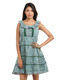

ID: 8484
Name: Forever New Women Floral Purple Dress
Category: Apparel
Gender: Women
------------


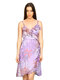

ID: 59985
Name: Avirate Women Green Dress
Category: Apparel
Gender: Women
------------


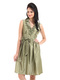

ID: 37941
Name: Mineral Women Floral Green Tunic
Category: Apparel
Gender: Women
------------


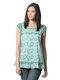

ID: 37938
Name: Mineral Women Green Dress
Category: Apparel
Gender: Women
------------


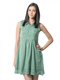

In [ ]:
show_search_results(I, df, images_path)


In [ ]:
query = "green floral dress"
inputs = tokenizer(query, return_tensors='pt', truncation=True, padding=True).to(device)
with torch.no_grad():
    query_emb = text_model(**inputs).last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

D, I = text_index.search(np.expand_dims(query_emb, axis=0).astype('float32'), k=5)
print(I)


[[21137 13878 30374 35177 29392]]


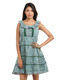

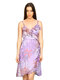

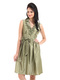

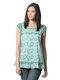

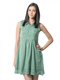

In [ ]:
from IPython.display import display

for idx in I[0]:
    img_file = df.iloc[idx]['image']
    img = Image.open(os.path.join(images_path, img_file)).convert('RGB')
    display(img)


ID: 49647
Name: Mineral Blue & Green Printed Dress
Category: Apparel
Image file: 49647.jpg
------------


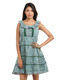

ID: 8484
Name: Forever New Women Floral Purple Dress
Category: Apparel
Image file: 8484.jpg
------------


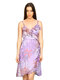

ID: 59985
Name: Avirate Women Green Dress
Category: Apparel
Image file: 59985.jpg
------------


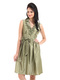

ID: 37941
Name: Mineral Women Floral Green Tunic
Category: Apparel
Image file: 37941.jpg
------------


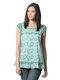

ID: 37938
Name: Mineral Women Green Dress
Category: Apparel
Image file: 37938.jpg
------------


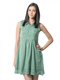

In [ ]:
from IPython.display import display
from PIL import Image

# Choose the correct index variable
indices = I[0]

for idx in indices:
    row = df.iloc[idx]
    print(f"ID: {row['id']}")
    print(f"Name: {row['productDisplayName']}")
    print(f"Category: {row['masterCategory']}")
    print(f"Image file: {row['image']}")
    print("------------")

    img_path = os.path.join(images_path, row['image'])
    img = Image.open(img_path)
    display(img)


In [ ]:
from PIL import Image
from IPython.display import display

def show_search_results(I, df, images_path, top_k=5):
    indices = I[0][:top_k]
    for idx in indices:
        row = df.iloc[idx]
        print(f"ID: {row['id']}")
        print(f"Name: {row['productDisplayName']}")
        print(f"Category: {row['masterCategory']}")
        print(f"Gender: {row['gender']}")
        print("------------")

        img_path = os.path.join(images_path, row['image'])
        img = Image.open(img_path)
        display(img)
